In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
n = 600

brands = np.random.choice(
    ["Toyota", "Honda", "Ford", "BMW", "Hyundai"],
    n,
    p=[0.25, 0.22, 0.2, 0.13, 0.2]
)

brand_premium = {
    "Toyota": 0,
    "Honda": 500,
    "Ford": -500,
    "BMW": 8000,
    "Hyundai": -1000
}

age = np.random.uniform(0, 15, n)

mileage = age * np.random.uniform(8000, 16000, n)

engine = np.random.uniform(1.0, 4.0, n)

fuel = np.random.choice(
    ["Petrol", "Diesel", "Electric"],
    n,
    p=[0.5, 0.35, 0.15]
)

fuel_premium = np.where(
    fuel == "Electric",
    4000,
    np.where(fuel == "Diesel", 800, 0)
)

base_price = 28000 - age * 1400 - mileage * 0.04 + engine * 1500

price = (
    base_price
    + np.array([brand_premium[b] for b in brands])
    + fuel_premium
    - np.random.normal(0, 1200, n)
)

price = np.clip(price, 1500, None)

veh_df = pd.DataFrame({
    "brand": brands,
    "age_years": age,
    "mileage_km": mileage,
    "engine_size_L": engine,
    "fuel_type": fuel,
    "price": price
})

In [ ]:
veh_df.head()

,brand,age_years,mileage_km,engine_size_L,fuel_type,price
0,Ford,14.072604,140725.940208,3.845400,Electric,14713.603742
1,BMW,0.585194,5262.987947,2.679109,Diesel,40492.176125
2,Ford,12.708636,109995.141960,3.690226,Electric,14756.577575
3,Ford,3.108229,45133.878664,2.792144,Electric,28328.419730
4,Honda,7.091550,94304.946749,2.971222,Diesel,20324.760167


In [ ]:
veh_df.shape

(600, 6)

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
num_feats = [
    "age_years",
    "mileage_km",
    "engine_size_L"
]

cat_feats = [
    "brand",
    "fuel_type"
]

In [ ]:
preprocess = ColumnTransformer([
    ("num", StandardScaler(), num_feats),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_feats)
])

In [ ]:
X = veh_df.drop(columns=["price"])
y = veh_df["price"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    )
}

In [ ]:
results = {}

for name, model in models.items():
    pipe = Pipeline([
        ("prep", preprocess),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)

    preds = pipe.predict(X_test)

    results[name] = {
        "MAE": mean_absolute_error(y_test, preds),
        "RMSE": mean_squared_error(y_test, preds) ** 0.5,
        "R2": r2_score(y_test, preds)
    }

    models[name] = pipe

In [ ]:
pd.DataFrame(results).T.round(2)

,MAE,RMSE,R2
Linear Regression,1034.48,1330.00,0.98
Random Forest,1540.20,1906.31,0.95
Gradient Boosting,1300.75,1632.39,0.97


In [ ]:
results_df = pd.DataFrame(results).T

best_model_name = results_df["RMSE"].idxmin()

print("Best Model:", best_model_name)

Best Model: Linear Regression


In [ ]:
best_model = models[best_model_name]

best_preds = best_model.predict(X_test)

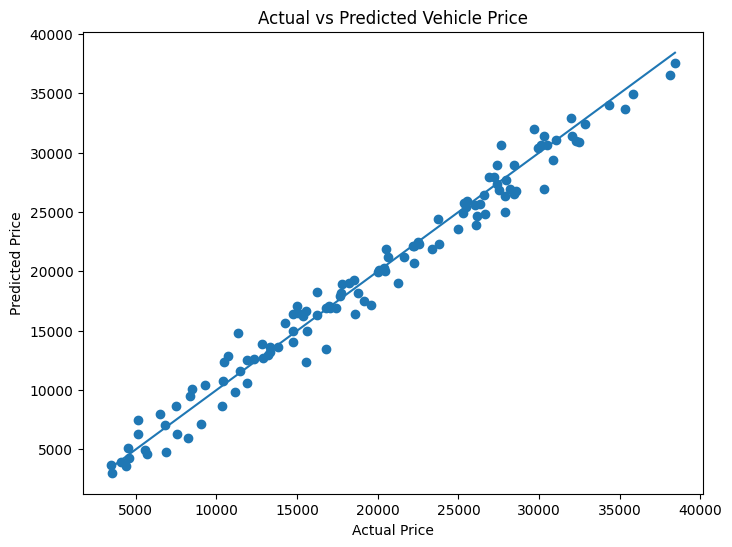

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, best_preds)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Vehicle Price")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.show()